# Setting

## Library

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Matplotlib global settings
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 20
plt.rcParams['savefig.dpi'] = 500
plt.rc('font', family='serif')

In [3]:
# ML libraries
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

In [4]:
# Helper functions & model import
sys.path.append(os.path.join('..', 'src'))
from helper import makeSpecColors
from paths import *
from var import *
from sdtpy import *
from model import *

## Function

In [5]:
def select_uids_by_class(df, sample_number, class_col='Class', uid_col='uid', random_state=42):
    np.random.seed(random_state)
    uids_by_class = {}
    for c in df[class_col].unique():
        uids = df[df[class_col]==c][uid_col].unique()
        n_select = min(sample_number, len(uids))
        selected_uids = np.random.choice(uids, n_select, replace=False)
        uids_by_class[c] = set(selected_uids)
    return uids_by_class

In [6]:
def filter_by_selected_uids(df, uids_by_class, class_col='Class', uid_col='uid'):
    mask = np.zeros(len(df), dtype=bool)
    for c, uids in uids_by_class.items():
        mask |= ((df[class_col]==c) & (df[uid_col].isin(uids)))
    return df[mask]

In [7]:
from sklearn.model_selection import GroupShuffleSplit

def train_test_split_by_uid(df, test_size=0.2, class_col='Class', uid_col='uid', random_state=42):
    groups = df[uid_col]
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, df[class_col], groups))
    return df.iloc[train_idx], df.iloc[test_idx]

## Initial Setup

In [8]:
logtxt = ""

In [9]:
path_catboost = os.path.join(MODEL, "Tune_CatBoost_40")
path_xgboost = os.path.join(MODEL, "Tune_XGBoost_40")
path_lightgbm = os.path.join(MODEL, "Tune_LightGBM_40")

model_params_dict = {
    "Catboost": os.path.join(path_catboost, "best_params.yaml"),
    "XGBoost": os.path.join(path_xgboost, "best_params.yaml"),
    "LightGBM": os.path.join(path_lightgbm, "best_params.yaml"),
}

model_params_dict

{'Catboost': '/home/gpaek/SED-Classifier/notebook/../model/Tune_CatBoost_40/best_params.yaml',
 'XGBoost': '/home/gpaek/SED-Classifier/notebook/../model/Tune_XGBoost_40/best_params.yaml',
 'LightGBM': '/home/gpaek/SED-Classifier/notebook/../model/Tune_LightGBM_40/best_params.yaml'}

In [10]:
# Set experiment configs
test_name = "New_Three_Models_and_Ensemble"
random_state = 42
test_size = 0.2
device_type = "cpu" # or gpu
n_jobs = 10
path_save = os.path.join(MODEL, test_name)
os.makedirs(path_save, exist_ok=True)

logtxt += "\nSet experiment configs\n"
logtxt += f"test_name: {test_name}\n"
logtxt += f"random_state: {random_state}\n"
logtxt += f"test_size: {test_size}\n"
logtxt += f"device_type: {device_type}\n"
logtxt += f"n_jobs: {n_jobs}\n"
logtxt += f"path_save: {path_save}\n"
logtxt += "\n"

- Source to Consider

In [11]:
sources_to_consider = [
	"AGN", 
	"Ia", 
	"II", 
	"Ibc", 
	# "LBV", 
	"TDE", 
	# "Nova", 
	# "M dwarf", 
	# "CV",
	"SLSN",
    "SV",
    "Asteroid",
]
logtxt += f"\nSources to consider: {sources_to_consider}\n"

In [12]:
path_data = os.path.join(FEATURE_NEW_DATA, 'features_40_color_only.csv')

logtxt += f"\nBalanced Data Set\n"

In [13]:
path_save = os.path.join(MODEL, "New_Three_Models_and_Ensemble")
os.makedirs(path_save, exist_ok=True)

# Data

In [14]:
columns_to_use = list(data_dtype_dict.keys())

In [15]:
data = pd.read_csv(
    path_data,
    engine='c', 
    usecols=columns_to_use,
    dtype=data_dtype_dict,
)

data['uid'] = data['uid'].astype(str)
data['Class'] = data['Class'].astype(str)
print(f"Balanced Data: {len(data)}")

logtxt += f"Balanced Data: {len(data)}\n"

indx_type_to_consider = np.where(
	np.array([(data['Class'] == source) for source in sources_to_consider]).any(axis=0)
)

print(f"{len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}")
data = data.iloc[indx_type_to_consider[0]]

logtxt += f"Balanced: {len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}\n"
logtxt += "\n"


Balanced Data: 80605
8 sources to consider: 80605


- Training and Test Data

In [16]:
# - Split features/target
X = data.drop(columns=['Sample_ID', 'Class', 'uid'])
X.fillna(-99, inplace=True)
y = data['Class']
uids = data['uid']


# - Split into train/test using GroupShuffleSplit by uid
gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
train_idx, test_idx = next(gss.split(X, y, groups=data['uid']))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

from catboost import CatBoostClassifier, Pool

# - Label encode class for ML
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
y_encoded = label_encoder.transform(y)
class_names = np.array([str(c) for c in label_encoder.inverse_transform(np.arange(len(label_encoder.classes_)))])
print("Balanced: Class mapping:", class_names)


Balanced: Class mapping: ['AGN' 'Asteroid' 'II' 'Ia' 'Ibc' 'SLSN' 'SV' 'TDE']


- Train data for each model 

In [17]:
from catboost import CatBoostClassifier, Pool
import lightgbm as lgb
import xgboost as xgb


In [18]:
import xgboost as xgb
train_data_xgb = xgb.DMatrix(X_train, label=y_train_encoded)
test_data_xgb = xgb.DMatrix(X_test, label=y_test_encoded)

In [19]:
import lightgbm as lgb
train_data_lgb = lgb.Dataset(X_train, label=y_train)
test_data_lgb = lgb.Dataset(X_test, label=y_test, reference=train_data_lgb)

In [20]:
from catboost import Pool
train_data_cat = Pool(X_train, label=y_train)
test_data_cat = Pool(X_test, label=y_test)

TBB Warning: The number of workers is currently limited to 19. The request for 79 workers is ignored. Further requests for more workers will be silently ignored until the limit changes.



In [21]:
del data

# Model

In [22]:
import time
from sklearn.metrics import mean_squared_error
from sklearn.metrics import f1_score
from xgboost.callback import EarlyStopping


from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

- Load Models

In [23]:
import pickle
import joblib

trained_cat_pickle = os.path.join(MODEL, "Tune_CatBoost_40", "catboost_7DT.pkl")
trained_xgb_pickle = os.path.join(MODEL, "Tune_XGBoost_40", "xgboost_7DT.pkl")
trained_lgb_pickle = os.path.join(MODEL, "Tune_LightGBM_40", "lightgbm_7DT.pkl")

model_cat = joblib.load(trained_cat_pickle)
model_xgb = joblib.load(trained_xgb_pickle)
model_lgb = joblib.load(trained_lgb_pickle)

In [24]:
prob_cat = model_cat.predict_proba(test_data_cat)
prob_xgb = model_xgb.predict(test_data_xgb)
prob_lgb = model_lgb.predict_proba(X_test)

## Ensemble Class

- Soft Voting

In [25]:
import numpy as np

class SoftVotingEnsemble:
    def __init__(self, model_cat, model_xgb, model_lgb,
                 test_data_cat, test_data_xgb, X_test):
        self.model_cat = model_cat
        self.model_xgb = model_xgb
        self.model_lgb = model_lgb
        self.test_data_cat = test_data_cat
        self.test_data_xgb = test_data_xgb
        self.X_test = X_test
        self.label_encoder = label_encoder

    def predict_proba(self):
        # 모델별 예측 확률 (하드코딩된 방식)
        prob_cat = self.model_cat.predict_proba(self.test_data_cat)
        prob_xgb = self.model_xgb.predict(self.test_data_xgb)
        prob_lgb = self.model_lgb.predict_proba(self.X_test)

        # xgboost output이 1차원이면 binary classification으로 가정하고 2차원으로 확장
        if prob_xgb.ndim == 1:
            prob_xgb = np.vstack([1 - prob_xgb, prob_xgb]).T

        # 세 모델의 확률 평균 (soft voting)
        avg_proba = np.mean([prob_cat, prob_xgb, prob_lgb], axis=0)
        return avg_proba

    def predict(self):
        proba = self.predict_proba()
        return np.argmax(proba, axis=1)

    def predict_label(self):
        return self.label_encoder.inverse_transform(self.predict())

In [26]:
soft_voter = SoftVotingEnsemble(
    model_cat=model_cat,
    model_xgb=model_xgb,
    model_lgb=model_lgb,
    test_data_cat=test_data_cat,
    test_data_xgb=test_data_xgb,
    X_test=X_test
)

# y_pred = soft_voter.predict()
# y_pred_label = label_encoder.inverse_transform(y_pred)
y_pred = soft_voter.predict_label()

# print(classification_report(y_test, y_pred_label, digits=3))

# classification_report 출력 및 dict 변환
report = classification_report(y_test, y_pred, output_dict=True)

# DataFrame으로 변환
df_s = pd.DataFrame(report).transpose()


- Weight Vote

In [27]:
import optuna
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

class WeightedSoftVotingEnsemble:
    def __init__(self, model_cat, model_xgb, model_lgb,
                 test_data_cat, test_data_xgb, X_test,
                 weights=(1.0, 1.0, 1.0),
                 label_encoder=None):
        self.model_cat = model_cat
        self.model_xgb = model_xgb
        self.model_lgb = model_lgb
        self.test_data_cat = test_data_cat
        self.test_data_xgb = test_data_xgb
        self.X_test = X_test
        self.weights = np.array(weights, dtype=float)
        self.label_encoder = label_encoder

    def predict_proba(self):
        prob_cat = self.model_cat.predict_proba(self.test_data_cat)
        prob_xgb = self.model_xgb.predict(self.test_data_xgb)
        prob_lgb = self.model_lgb.predict_proba(self.X_test)

        if prob_xgb.ndim == 1:
            prob_xgb = np.vstack([1 - prob_xgb, prob_xgb]).T

        weighted_sum = (
            self.weights[0] * prob_cat +
            self.weights[1] * prob_xgb +
            self.weights[2] * prob_lgb
        )
        normalized_proba = weighted_sum / self.weights.sum()
        return normalized_proba

    def predict(self):
        proba = self.predict_proba()
        return np.argmax(proba, axis=1)

    def predict_label(self):
        return self.label_encoder.inverse_transform(self.predict())

    def optimize_weights(self, y_true, metric="f1", n_trials=50, timeout=None, verbose=True):
        """
        Optuna 기반 모델별 weight 최적화
        """

        def objective(trial):
            w_cat = trial.suggest_float("w_cat", 0.1, 2.0)
            w_xgb = trial.suggest_float("w_xgb", 0.1, 2.0)
            w_lgb = trial.suggest_float("w_lgb", 0.1, 2.0)

            self.weights = np.array([w_cat, w_xgb, w_lgb])
            y_pred = self.predict()

            if metric == 'accuracy':
                return accuracy_score(y_true, y_pred)
            elif metric == 'f1':
                return f1_score(y_true, y_pred, average='macro')
            else:
                raise ValueError("metric must be 'accuracy' or 'f1'")

        # suppress optuna logs
        optuna.logging.set_verbosity(optuna.logging.WARNING)

        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=n_trials, timeout=timeout)

        best_trial = study.best_trial
        best_weights = np.array([
            best_trial.params["w_cat"],
            best_trial.params["w_xgb"],
            best_trial.params["w_lgb"]
        ])

        self.weights = best_weights
        if verbose:
            rounded_best = tuple(round(w, 2) for w in best_weights)
            print(f"\n🎯 Best Weights by {metric}: {rounded_best}, Score: {best_trial.value:.4f}")

        return best_weights, best_trial.value

In [28]:
weight_voter = WeightedSoftVotingEnsemble(
    model_cat=model_cat,
    model_xgb=model_xgb,
    model_lgb=model_lgb,
    test_data_cat=test_data_cat,
    test_data_xgb=test_data_xgb,
    X_test=X_test,
    label_encoder=label_encoder
)

best_weights, best_score = weight_voter.optimize_weights(
    y_true=y_test_encoded,
    metric='f1',
    n_trials=50,
    timeout=600
)

y_pred = weight_voter.predict_label()

# classification_report 출력 및 dict 변환
report = classification_report(y_test, y_pred, output_dict=True)

# DataFrame으로 변환
df_w = pd.DataFrame(report).transpose()

# y_pred_label = label_encoder.inverse_transform(y_pred)
# print(classification_report(y_test, y_pred, digits=3))


🎯 Best Weights by f1: (1.55, 1.43, 1.17), Score: 0.8300


- Class-wise Weighted Voting

In [29]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import numpy as np
from sklearn.metrics import f1_score, accuracy_score

class ClasswiseWeightedVotingEnsemble:
    def __init__(self,
                 model_cat, model_xgb, model_lgb,
                 test_data_cat, test_data_xgb, X_test,
                 class_weights=None,
                 label_encoder=None):
        self.model_cat = model_cat
        self.model_xgb = model_xgb
        self.model_lgb = model_lgb
        self.test_data_cat = test_data_cat
        self.test_data_xgb = test_data_xgb
        self.X_test = X_test
        self.label_encoder = label_encoder
        self.class_weights = class_weights

    def predict_proba(self):
        prob_cat = self.model_cat.predict_proba(self.test_data_cat)
        prob_xgb = self.model_xgb.predict(self.test_data_xgb)
        prob_lgb = self.model_lgb.predict_proba(self.X_test)

        if prob_xgb.ndim == 1:
            prob_xgb = np.vstack([1 - prob_xgb, prob_xgb]).T

        probas = [prob_cat, prob_xgb, prob_lgb]

        if self.class_weights is None:
            n_classes = prob_cat.shape[1]
            self.class_weights = [np.ones(n_classes)] * 3

        weighted_sum = np.zeros_like(prob_cat)
        total_weights = np.zeros_like(prob_cat)

        for prob, weight in zip(probas, self.class_weights):
            weight = weight.reshape(1, -1)
            weighted_sum += prob * weight
            total_weights += weight

        return weighted_sum / total_weights

    def predict(self):
        proba = self.predict_proba()
        return np.argmax(proba, axis=1)

    def predict_label(self):
        return self.label_encoder.inverse_transform(self.predict())

    def optimize_class_weights(self, y_true, metric="f1", n_trials=50, timeout=None, verbose=True):
        """
        각 모델의 클래스별 weight를 optuna를 통해 최적화
        """

        n_classes = self.model_cat.predict_proba(self.test_data_cat).shape[1]

        def objective(trial):
            # 각 모델당 n_classes 개의 weight
            cw_cat = np.array([trial.suggest_float(f"w_cat_{i}", 0.2, 2.0) for i in range(n_classes)])
            cw_xgb = np.array([trial.suggest_float(f"w_xgb_{i}", 0.2, 2.0) for i in range(n_classes)])
            cw_lgb = np.array([trial.suggest_float(f"w_lgb_{i}", 0.2, 2.0) for i in range(n_classes)])

            self.class_weights = [cw_cat, cw_xgb, cw_lgb]
            y_pred = self.predict()

            if metric == 'f1':
                score = f1_score(y_true, y_pred, average='macro')
            elif metric == 'accuracy':
                score = accuracy_score(y_true, y_pred)
            else:
                raise ValueError("metric must be 'f1' or 'accuracy'")

            return score

        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=n_trials, timeout=timeout)

        # best weights 설정
        best_trial = study.best_trial
        best_cw_cat = np.array([best_trial.params[f"w_cat_{i}"] for i in range(n_classes)])
        best_cw_xgb = np.array([best_trial.params[f"w_xgb_{i}"] for i in range(n_classes)])
        best_cw_lgb = np.array([best_trial.params[f"w_lgb_{i}"] for i in range(n_classes)])

        self.class_weights = [best_cw_cat, best_cw_xgb, best_cw_lgb]

        if verbose:
            print(f"\n🎯 Best score: {best_trial.value:.4f}")
            print(f"Best class weights (CatBoost): {np.round(best_cw_cat, 2)}")
            print(f"Best class weights (XGBoost): {np.round(best_cw_xgb, 2)}")
            print(f"Best class weights (LightGBM): {np.round(best_cw_lgb, 2)}")

        return self.class_weights, best_trial.value

In [30]:
cweight_voter = ClasswiseWeightedVotingEnsemble(
    model_cat=model_cat,
    model_xgb=model_xgb,
    model_lgb=model_lgb,
    test_data_cat=test_data_cat,
    test_data_xgb=test_data_xgb,
    X_test=X_test,
    label_encoder=label_encoder
)

best_weights, best_score = cweight_voter.optimize_class_weights(
    y_true=y_test_encoded,
    metric="f1",
    n_trials=100,
    timeout=600,  # seconds
    verbose=True
)

y_pred = cweight_voter.predict_label()
# y_pred_label = label_encoder.inverse_transform(y_pred)

# classification_report 출력 및 dict 변환
report = classification_report(y_test, y_pred, output_dict=True)

# DataFrame으로 변환
df_cw = pd.DataFrame(report).transpose()


🎯 Best score: 0.8314
Best class weights (CatBoost): [1.35 1.47 1.75 1.57 1.13 1.11 1.48 0.43]
Best class weights (XGBoost): [1.03 1.74 1.13 1.72 0.96 0.98 1.78 0.31]
Best class weights (LightGBM): [0.8  0.82 1.86 1.82 0.26 0.83 0.94 1.  ]


# Compare

In [31]:
from sklearn.metrics import classification_report

# 각 모델의 예측값
y_pred_cat = np.argmax(prob_cat, axis=1)
y_pred_xgb = np.argmax(prob_xgb, axis=1)
y_pred_lgb = np.argmax(prob_lgb, axis=1)

# y_test_encoded는 이미 숫자 라벨로 되어 있다고 가정
# label_encoder는 클래스명을 복원하기 위한 encoder

# 각 모델에 대해 classification report → DataFrame
def get_report_df(y_true, y_pred, label_encoder, digits=3):
    report_dict = classification_report(
        y_true, y_pred, target_names=label_encoder.classes_, output_dict=True
    )
    return pd.DataFrame(report_dict).T.round(digits)

# 생성
df_cat = get_report_df(y_test_encoded, y_pred_cat, label_encoder)
df_xgb = get_report_df(y_test_encoded, y_pred_xgb, label_encoder)
df_lgb = get_report_df(y_test_encoded, y_pred_lgb, label_encoder)

In [32]:
# 이름과 각 classification report를 딕셔너리로 묶기
reports = {
    "CatBoost": df_cat,
    "XGBoost": df_xgb,
    "LightGBM": df_lgb,
    "SoftVote": df_s,
    "WeightedVote": df_w,
    "ClasswiseVote": df_cw,
}

In [33]:
# 모델 이름과 고정 색상 매핑
model_colors = {
    "CatBoost": "#1f77b4",        # 파랑
    "XGBoost": "#ff7f0e",         # 주황
    "LightGBM": "#2ca02c",        # 녹색
    "SoftVote": "#d62728",        # 빨강
    "WeightedVote": "#9467bd",    # 보라
    "ClasswiseVote": "#8c564b",   # 갈색
}

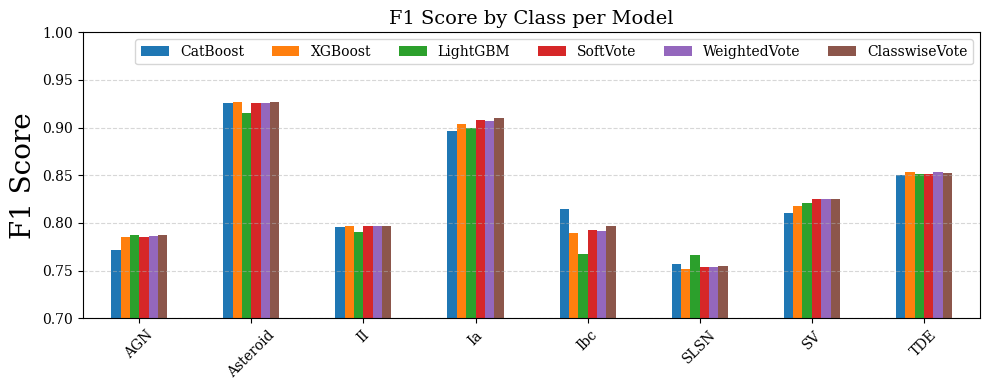

In [34]:
# 클래스 이름 가져오기
class_names = [label for label in df_cat.index if label not in ['accuracy', 'macro avg', 'weighted avg']]

# 각 모델별 클래스별 f1-score 추출
f1_scores_by_class = pd.DataFrame({
    model: df.loc[class_names, "f1-score"]
    for model, df in reports.items()
}, index=class_names)

# 모델별 색상 순서 정의
color_list = [model_colors[model] for model in f1_scores_by_class.columns]

# 시각화
f1_scores_by_class.plot(kind='bar', figsize=(10, 4), color=color_list)
plt.title("F1 Score by Class per Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.ylim(0.70, 1.0)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(ncol=6)
plt.tight_layout()
plt.show()

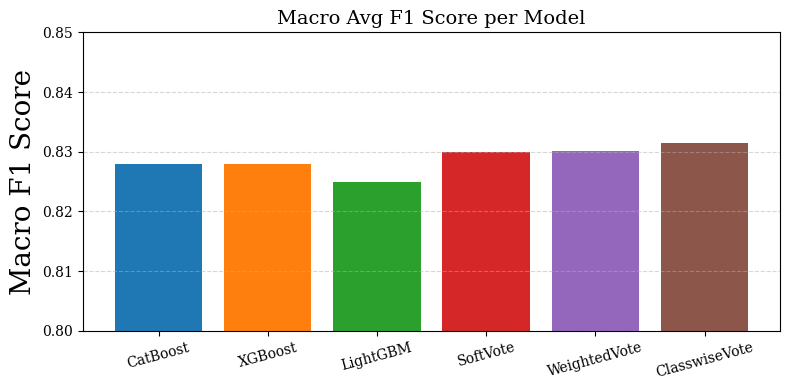

In [35]:
# macro f1 score 추출
macro_f1_scores = {
    model: df.loc["macro avg", "f1-score"]
    for model, df in reports.items()
}

# 색상 리스트
color_list = [model_colors[model] for model in macro_f1_scores.keys()]

# 시각화
plt.figure(figsize=(8, 4))
plt.bar(macro_f1_scores.keys(), macro_f1_scores.values(), color=color_list)
plt.title("Macro Avg F1 Score per Model")
plt.ylabel("Macro F1 Score")
plt.ylim(0.8, 0.85)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

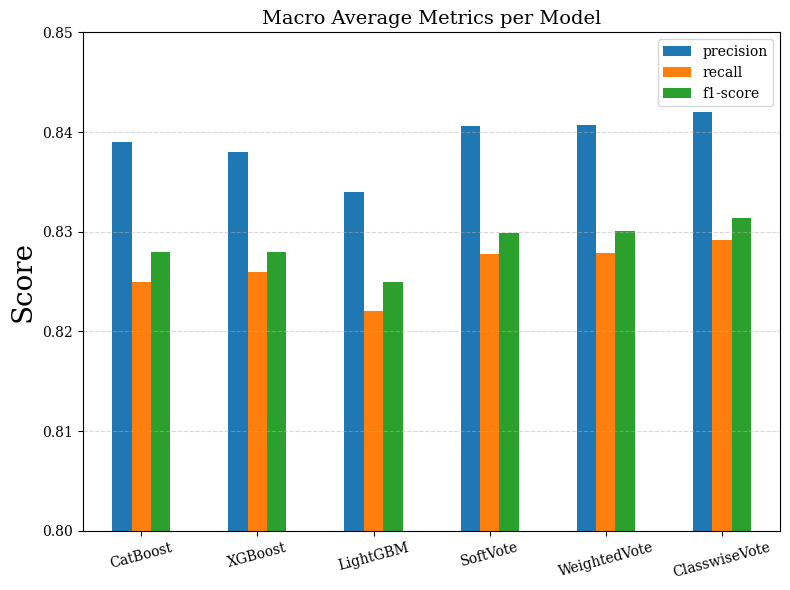

In [36]:
# macro 평균 precision, recall, f1 추출
macro_metrics = pd.DataFrame({
    model: df.loc["macro avg", ["precision", "recall", "f1-score"]]
    for model, df in reports.items()
}).T

# 시각화
ax = macro_metrics.plot(kind="bar", figsize=(8, 6), color=['#1f77b4', '#ff7f0e', '#2ca02c'])  # 기본 3색
plt.title("Macro Average Metrics per Model")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0.8, 0.85)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Feature Importance

## Mean Feature Importance

In [37]:
# # 다중 클래스 shap_values (list of arrays) 처리
# def compute_importance(shap_values):
#     if isinstance(shap_values, list):
#         # shape: (n_classes, n_features), 평균 across classes
#         return np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
#     else:
#         return np.abs(shap_values).mean(axis=0)

In [38]:
def compute_importance(shap_values, target_class=None, class_names=None):
    """
    SHAP feature importance 계산 함수

    Parameters
    ----------
    shap_values : array or list of arrays
        SHAP explainer에서 나온 shap_values (binary or multiclass)
    target_class : None, int, or str
        - None: 전체 클래스 평균
        - int: 해당 클래스 index만
        - str: class_names에서 이름 기반 매핑
    class_names : list of str
        클래스 인덱스를 이름으로 매핑할 때 사용하는 리스트

    Returns
    -------
    importance : np.array
        shape = (n_features,)의 feature importance 벡터
    """
    # 다중 클래스
    if isinstance(shap_values, list):
        if target_class is None:
            # 전체 클래스 평균
            return np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
        else:
            # 특정 클래스만
            if isinstance(target_class, str):
                if class_names is None:
                    raise ValueError("class_names must be provided when target_class is a string.")
                if target_class not in class_names:
                    raise ValueError(f"{target_class} not found in class_names.")
                target_class = class_names.index(target_class)
            # 이제 target_class는 int
            return np.abs(shap_values[target_class]).mean(axis=0)

    # 이진 분류 or 회귀
    else:
        return np.abs(shap_values).mean(axis=0)

In [39]:
import shap

# 환경변수로 core 제한 (추가 안정성 확보)
os.environ["OMP_NUM_THREADS"] = "15"
os.environ["MKL_NUM_THREADS"] = "15"
os.environ["TBB_NUM_THREADS"] = "15"

# 데이터 샘플링
X_sample = X_train.sample(n=1000, random_state=42)

# SHAP explainer 계산 (TreeExplainer는 model structure 사용)
explainer_cat = shap.TreeExplainer(model_cat)
shap_values_cat = explainer_cat.shap_values(X_sample)
# importance_cat = np.abs(shap_values_cat).mean(axis=0)

explainer_xgb = shap.TreeExplainer(model_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_sample)
# importance_xgb = np.abs(shap_values_xgb).mean(axis=0)

explainer_lgb = shap.TreeExplainer(model_lgb)
shap_values_lgb = explainer_lgb.shap_values(X_sample)
# importance_lgb = np.abs(shap_values_lgb).mean(axis=0)


In [40]:
importance_cat = compute_importance(shap_values_cat)
importance_xgb = compute_importance(shap_values_xgb)
importance_lgb = compute_importance(shap_values_lgb)

In [41]:
# Normalize
nor_mean_importance_xgb = importance_xgb / importance_xgb.sum()
nor_mean_importance_cat = importance_cat / importance_cat.sum()
nor_mean_importance_lgb = importance_lgb / importance_lgb.sum()

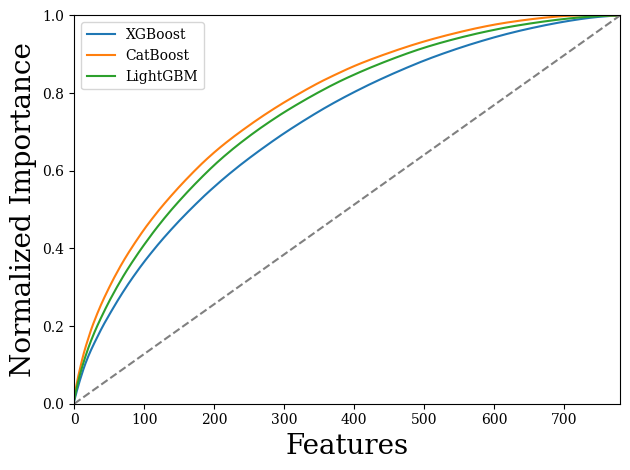

In [42]:
for model_name, imp_values in zip(["XGBoost", "CatBoost", "LightGBM"], [nor_mean_importance_xgb, nor_mean_importance_cat, nor_mean_importance_lgb]):

    indx_sort = np.argsort(-1*imp_values)
    sorted_nor_mean_imp = imp_values[indx_sort]
    cum_mean_imp = np.cumsum(sorted_nor_mean_imp)
    plt.plot(cum_mean_imp, label=model_name)

plt.plot([0, len(sorted_nor_mean_imp)], [0, 1], ls='--', c='grey')

_ = plt.xlabel("Features")
_ = plt.ylabel("Normalized Importance")
plt.xlim(0, len(sorted_nor_mean_imp))
plt.ylim(0, 1)
plt.legend(loc='upper left')
plt.tight_layout()

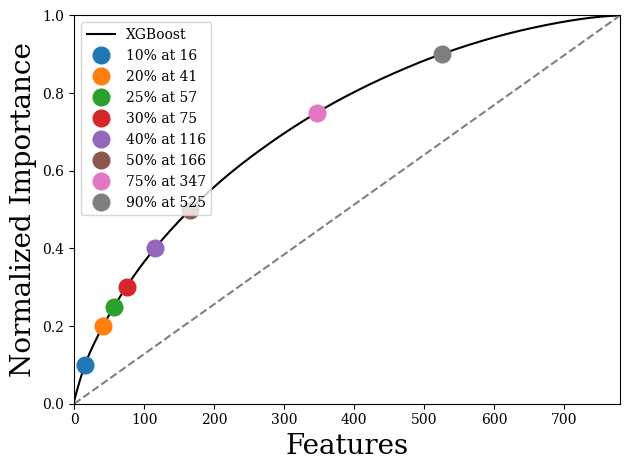

XGBoost - Top 10% Importance → 16 features
XGBoost - Top 20% Importance → 41 features
XGBoost - Top 25% Importance → 57 features
XGBoost - Top 30% Importance → 75 features
XGBoost - Top 40% Importance → 116 features
XGBoost - Top 50% Importance → 166 features
XGBoost - Top 75% Importance → 347 features
XGBoost - Top 90% Importance → 525 features


<Figure size 640x480 with 0 Axes>

In [46]:
# 기존 시각화 코드 확장
thresholds = [0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.75, 0.9]
# colors = ['orange', 'green', 'red', 'blue', 'purple']
xgb_lines = []

for model_name, imp_values in zip(["XGBoost",],
                                   [nor_mean_importance_xgb,]):

    indx_sort = np.argsort(-1 * imp_values)
    sorted_nor_mean_imp = imp_values[indx_sort]
    cum_mean_imp = np.cumsum(sorted_nor_mean_imp)
    plt.plot(cum_mean_imp, label=model_name, c='k')

    # ✅ XGBoost에 대해서만 threshold 수직선 추가
    if model_name == "XGBoost":
        # for t, c in zip(thresholds, colors):
        for t in thresholds:
            idx = np.searchsorted(cum_mean_imp, t)
            # plt.axvline(x=idx, linestyle='--', color=c, label=f"{int(t*100)}% at {idx}")
            plt.plot([idx], [t], ms=12, marker='o', ls='none', label=f"{int(t*100)}% at {idx}")
            xgb_lines.append((t, idx))
            #
            selected_features = X.columns.values[indx_sort][:idx].tolist()
            output_path = os.path.join(path_save, f"xgboost_top_{int(t*100)}p_features.json")
            with open(output_path, 'w') as f:
                json.dump(selected_features, f, indent=2)

# 기준선
plt.plot([0, len(sorted_nor_mean_imp)], [0, 1], ls='--', c='grey',)# label='1-to-1 Line')

# 축 설정
plt.xlabel("Features")
plt.ylabel("Normalized Importance")
plt.xlim(0, len(sorted_nor_mean_imp))
plt.ylim(0, 1)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# 선택된 feature 개수 출력
for t, idx in xgb_lines:
    print(f"XGBoost - Top {int(t*100)}% Importance → {idx} features")

plt.savefig(f"{path_save}/feature_importance_xgb.png")




In [44]:
stop

NameError: name 'stop' is not defined

In [ ]:
# DataFrame
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'CatBoost': nor_mean_importance_cat,
    'XGBoost': nor_mean_importance_xgb,
    'LightGBM': nor_mean_importance_lgb,
}).set_index('Feature')

In [ ]:
import matplotlib.cm as cm

# 설정
# methods = ['CatBoost', 'XGBoost', 'LightGBM', 'Soft Voting', 'Weighted Voting', 'Class-weighted Voting']
methods = ['CatBoost', 'XGBoost', 'LightGBM',]# 'Soft Voting', 'Weighted Voting', 'Class-weighted Voting']
n_methods = len(methods)
n_cols = 3
n_rows = (n_methods + n_cols - 1) // n_cols  # 올림 나눗셈
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 7 * n_rows), squeeze=False)

# 컬러맵에서 기본 색상 추출 (tab10 등 sequential colormap 활용 가능)
colors = plt.cm.tab10(np.linspace(0, 1, n_methods))

# 각 subplot에 그래프 그리기
for i, met in enumerate(methods):
    row, col = divmod(i, n_cols)
    ax = axes[row][col]

    importance_df_sorted = importance_df.sort_values(by=met, ascending=False).head(20)

    # 막대 그리기 (테두리: 검정색, 채움색: 모델별 색상)
    ax.barh(
        importance_df_sorted.index,
        importance_df_sorted[met],
        color=colors[i],
        edgecolor='black'
    )
    ax.invert_yaxis()
    ax.set_title(f"Top 20 Features ({met})", fontsize=14)
    if i == 4:
        ax.set_xlabel("Normalized Mean(|SHAP Value|)")
    ax.tick_params(axis='both', labelsize=10)

# 빈 subplot 숨기기
for i in range(len(methods), n_rows * n_cols):
    row, col = divmod(i, n_cols)
    axes[row][col].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
feature_score_table = Table()
feature_score_table['feature'] = feature_names
for filte in MEDIUM_BANDS:
    feature_score_table[filte] = 0.0

feature_score_table

In [ ]:
default_score = 0.0

for ff, feature in enumerate(feature_score_table['feature']):

    filter0 = feature.split('-')[0]
    filter1 = feature.split('-')[1]

    feature_score_table[filter0][ff] = default_score
    feature_score_table[filter1][ff] = default_score

feature_score_table[:3]

In [ ]:
xgb_score_table = feature_score_table.copy()

for ff, feature in enumerate(xgb_score_table['feature']):

    weight = nor_mean_importance_xgb[ff]

    filter0 = feature.split('-')[0]
    filter1 = feature.split('-')[1]

    xgb_score_table[filter0][ff] += weight
    xgb_score_table[filter1][ff] += weight

xgb_score_table[:3]

In [ ]:
xgb_total_filter_scores = np.array([xgb_score_table[filte].sum() for filte in MEDIUM_BANDS])
#
xgb_sorted_MEDIUM_BANDS = np.array(MEDIUM_BANDS)[np.argsort(-1*xgb_total_filter_scores)]
xgb_top20_filters = xgb_sorted_MEDIUM_BANDS[:20]
xgb_top20_filters
#
plt.figure(figsize=(10, 4))
plt.bar(MEDIUM_BANDS, xgb_total_filter_scores, width=0.5,)
_ = plt.xticks(rotation=90)
plt.ylabel("Importance")
plt.tight_layout()

xgb_top20_filters


In [ ]:
colors = makeSpecColors(len(MEDIUM_BANDS))[::-1]

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.cm as cmx
import numpy as np

# 1. Normalize importance for colormap scaling
norm = plt.Normalize(vmin=xgb_total_filter_scores.min(), vmax=xgb_total_filter_scores.max())
cmap = plt.cm.viridis  # 또는 'plasma', 'coolwarm', 'YlOrRd'

colors_imp = cmap(norm(xgb_total_filter_scores))

# 2. Plot 구성
fig, (ax_rect, ax_bar) = plt.subplots(2, 1, figsize=(12, 5), height_ratios=[0.3, 1], sharex=True)

# 3. 위쪽 색상 사각형 (1x40)
for i, (filter_name, color) in enumerate(zip(MEDIUM_BANDS, colors_imp)):
    ax_rect.add_patch(plt.Rectangle((i - 0.5, 0), 1, 1, color=color))

ax_bar.set_xlim(-0.5, len(MEDIUM_BANDS) - 0.5)
ax_rect.set_xlim(-0.5, len(MEDIUM_BANDS) - 0.5)

ax_rect.axis('off')

# 4. 아래쪽 Bar plot
# ax_bar.bar(np.arange(len(MEDIUM_BANDS)), xgb_total_filter_scores, color='steelblue', width=0.8)
ax_bar.bar(np.arange(len(MEDIUM_BANDS)), xgb_total_filter_scores, color=colors, width=0.8, edgecolor='black')
ax_bar.set_xticks(np.arange(len(MEDIUM_BANDS)))
ax_bar.set_xticklabels(MEDIUM_BANDS, rotation=90)
ax_bar.set_ylabel("Importance")
ax_bar.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Tight layout
plt.tight_layout()
plt.show()

In [ ]:
selected_features = []
non_selected_features = []

for ff, feature in enumerate(feature_names):

    filter0 = feature.split('-')[0]
    filter1 = feature.split('-')[1]

    if (filter0 in xgb_top20_filters) & (filter1 in xgb_top20_filters):
        selected_features.append(feature)
    elif (filter0 not in xgb_top20_filters) & (filter1 not in xgb_top20_filters):
        non_selected_features.append(feature)
    else:
        pass
print(f"{len(selected_features)} features selected for top20 filters")
print(f"{len(non_selected_features)} non-features selected for bottom20 filters")

# selected_features
# non_selected_features

## Class-wise Feature importance 

In [ ]:
class_names = ['AGN', 'Asteroid', 'II', 'Ia', 'Ibc', 'SLSN', 'SV', 'TDE']

for target_class_name in class_names:
    importance_cat_cls = compute_importance(shap_values_cat, target_class=target_class_name, class_names=class_names)
    importance_xgb_cls = compute_importance(shap_values_xgb, target_class=target_class_name, class_names=class_names)
    importance_lgb_cls = compute_importance(shap_values_lgb, target_class=target_class_name, class_names=class_names)
    
    # normalize
    importance_cat_cls /= importance_cat_cls.sum()
    importance_xgb_cls /= importance_xgb_cls.sum()
    importance_lgb_cls /= importance_lgb_cls.sum()
    
    importance_df_cls = pd.DataFrame({
        "Feature": feature_names,
        "CatBoost": importance_cat_cls,
        "XGBoost": importance_xgb_cls,
        "LightGBM": importance_lgb_cls,
    }).set_index("Feature")
    
    
    # 예시: 상위 20개 feature 시각화
    n_methods = len(methods)
    colors_bar = plt.cm.tab10(np.linspace(0, 1, n_methods))
    
    fig, axes = plt.subplots(1, n_methods, figsize=(5 * n_methods, 6), squeeze=False)
    
    for i, met in enumerate(methods):
        ax = axes[0][i]
        df_sorted = importance_df_cls.sort_values(by=met, ascending=False).head(20)
        ax.barh(df_sorted.index, df_sorted[met], color=colors_bar[i], edgecolor='black')
        ax.invert_yaxis()
        ax.set_title(f"{met} - {target_class_name}", fontsize=14)
        ax.set_xlabel("Normalized SHAP Importance")
        ax.tick_params(axis='both', labelsize=10)
    
    plt.tight_layout()
    plt.show()

    # - - - - -
    
    xgb_score_table = feature_score_table.copy()
    
    for ff, feature in enumerate(xgb_score_table['feature']):
    
        weight = importance_xgb_cls[ff]
    
        filter0 = feature.split('-')[0]
        filter1 = feature.split('-')[1]
    
        xgb_score_table[filter0][ff] += weight
        xgb_score_table[filter1][ff] += weight
    
    
    xgb_total_filter_scores = np.array([xgb_score_table[filte].sum() for filte in MEDIUM_BANDS])
    #
    xgb_sorted_MEDIUM_BANDS = np.array(MEDIUM_BANDS)[np.argsort(-1*xgb_total_filter_scores)]
    xgb_top20_filters = xgb_sorted_MEDIUM_BANDS[:20]

    
    # 1. Normalize importance for colormap scaling
    norm = plt.Normalize(vmin=xgb_total_filter_scores.min(), vmax=xgb_total_filter_scores.max())
    cmap = plt.cm.viridis  # 또는 'plasma', 'coolwarm', 'YlOrRd'
    
    colors_imp = cmap(norm(xgb_total_filter_scores))
    
    # 2. Plot 구성
    fig, (ax_rect, ax_bar) = plt.subplots(2, 1, figsize=(12, 5), height_ratios=[0.3, 1], sharex=True)
    
    # 3. 위쪽 색상 사각형 (1x40)
    for i, (filter_name, color) in enumerate(zip(MEDIUM_BANDS, colors_imp)):
        ax_rect.add_patch(plt.Rectangle((i - 0.5, 0), 1, 1, color=color))
    
    ax_bar.set_xlim(-0.5, len(MEDIUM_BANDS) - 0.5)
    ax_rect.set_xlim(-0.5, len(MEDIUM_BANDS) - 0.5)
    
    ax_rect.axis('off')
    
    # 4. 아래쪽 Bar plot
    # ax_bar.bar(np.arange(len(MEDIUM_BANDS)), xgb_total_filter_scores, color='steelblue', width=0.8)
    ax_bar.bar(np.arange(len(MEDIUM_BANDS)), xgb_total_filter_scores, color=colors, width=0.8, edgecolor='black')
    ax_bar.set_xticks(np.arange(len(MEDIUM_BANDS)))
    ax_bar.set_xticklabels(MEDIUM_BANDS, rotation=90)
    ax_bar.set_ylabel("Importance")
    ax_bar.grid(axis='y', linestyle='--', alpha=0.5)
    ax_bar.set_title(f"{target_class_name}", fontsize=14)
    
    # 5. Tight layout
    plt.tight_layout()
    plt.savefig(f"{path_save}/xgboost_{target_class_name}_filter_importance.png")
    plt.show()
    # break 

## Sensitivity vs Feature Importance 

In [ ]:
# 7DT Setting
sys.path.append('..')
from simulator.helper import *
from simulator.sdtpy import *
register_custom_filters_on_speclite('../simulator')

#	Exposure Time [s]
sdt = SevenDT()
sdt.echo_optics()
filterset = sdt.generate_filterset(bandmin=BANDMIN, bandmax=BANDMAX, bandwidth=BANDWIDTH, bandstep=BANDSTEP, bandrsp=BANDRSP, lammin=LAMMIN, lammax=LAMMAX, lamres=LAMRES)
T_qe = sdt.get_CMOS_IMX455_QE()
sdt.get_optics()
s = sdt.get_sky()
sdt.smooth_sky()
totrsptbl = sdt.calculate_response()
Npix_ptsrc, Narcsec_ptsrc = sdt.get_phot_aperture(exptime=EXPTIME_SINGLE, fwhm_seeing=SEEING, optfactor=EFF_FACTOR, verbose=False)
depthtbl = sdt.get_depth_table(Nsigma=5)
sdt.get_speclite()

In [ ]:
totrsptbl[:3]

In [ ]:
rsp_arr = []

for filte in np.unique(totrsptbl['name']):
    rsp = totrsptbl['response'][totrsptbl['name'] == filte]
    max_rsp = np.max(rsp)
    # print(filtername, max_rsp)
    rsp_arr.append(max_rsp)

rsp_arr = np.array(rsp_arr)

In [ ]:
total_scores

In [ ]:
colors = makeSpecColors(len(MEDIUM_BANDS), palette='Spectral')[::-1]

plt.scatter(rsp_arr, xgb_total_filter_scores, marker='o', c=colors, ec='k')

score_threshold = 0.05
resp_threshold = 0.9
for filte, resp_value, score in zip(MEDIUM_BANDS, rsp_arr, xgb_total_filter_scores):
    if (score > score_threshold) & (resp_value < resp_threshold):
        plt.text(resp_value, score, s=filte)

plt.xlabel("Maximum Response [%]")
plt.ylabel("Importance")

# Result Save

In [ ]:
path_final_models = os.path.join(MODEL, "final_normal_class_model")
os.makedirs(path_final_models, exist_ok=True)

In [ ]:
# CatBoost
cat_model.save_model(os.path.join(path_final_models, "catboost_model.cbm"))

# XGBoost
xgb_model.save_model(os.path.join(path_final_models, "xgboost_model.json"))  # or .bst

# LightGBM
import joblib
joblib.dump(lgbm_model, os.path.join(path_final_models, "lightgbm_model.pkl"))

In [ ]:
import numpy as np
import joblib
import shap
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 모델 불러오기
def load_ensemble_models(cat_path, xgb_path, lgb_path):
    cat = CatBoostClassifier()
    cat.load_model(cat_path)

    xgb = XGBClassifier()
    xgb.load_model(xgb_path)

    lgb = joblib.load(lgb_path)

    return cat, xgb, lgb

# 예측 함수 정의
def ensemble_predict(X, cat, xgb, lgb, weights=None):
    """
    Args:
        X: input features (DataFrame or ndarray)
        cat, xgb, lgb: trained model instances
        weights: None for soft voting, or list like [w_cat, w_xgb, w_lgb]
    Returns:
        pred_class: final predicted class index
        pred_probs: averaged or weighted probability
    """
    p_cat = cat.predict_proba(X)
    p_xgb = xgb.predict_proba(X)
    p_lgb = lgb.predict_proba(X)

    if weights is None:
        # soft voting
        probs = (p_cat + p_xgb + p_lgb) / 3
    else:
        probs = (
            p_cat * weights[0] +
            p_xgb * weights[1] +
            p_lgb * weights[2]
        )

    pred_class = np.argmax(probs, axis=1)
    return pred_class, probs

In [ ]:
# Load models
cat, xgb, lgb = load_ensemble_models(
    os.path.join(path_final_models, "catboost_model.cbm"),
    os.path.join(path_final_models, "xgboost_model.json"),
    os.path.join(path_final_models, "lightgbm_model.pkl"),
)

# Predict
y_pred, y_probs = ensemble_predict(X_test, cat, xgb, lgb, weights=best_weights)

In [ ]:
import json
json.dump({"weights": [val for val in best_weights]}, open(os.path.join(path_final_models, "ensemble_weights.json"), "w"))